# 03 — Modelagem

**Dimensão 5 da rúbrica — 20 pontos.**

Mínimo de **dois** classificadores distintos. Um único modelo zera 8 dos 20 pontos.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW_CREDIT_RECORD= Path("..") / "data" / "raw" / "credit_record.csv"          # PREENCHER: nome do arquivo
RAW_APPLICATION_RECORD= Path("..") / "data" / "raw" / "application_record.csv"
PROCESSED = Path("..") / "data" / "processed" / "df_application_record_tratado.csv"
TARGET = "TARGET"                                            # PREENCHER: variável alvo

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(PROCESSED)

## Dicionário do dataset df_application_record_tratado.csv
| Nome da Coluna | Tipo de Dado | Descrição / Significado / Valores Mapeados |
| :---: | :---: | :---: |
| **NAME_EDUCATION_TYPE** | float64 | Grau de escolaridade codificado ordinalmente:<br>**0.0**: Ensino Fundamental (`Lower secondary`) <br>**1.0**: Ensino Médio (`Secondary / secondary special`) <br>**2.0**: Ensino Superior Incompleto (`Incomplete higher`) <br>**3.0**: Ensino Superior Completo (`Higher education`) <br>**4.0**: Pós-graduação (`Academic degree`) |
| **NAME_INCOME_TYPE_Pensioner** | float64 | Flag binária (`1.0` ou `0.0`). Indica se o tipo de renda é Pensionista. |
| **NAME_INCOME_TYPE_State servant** | float64 | Flag binária (`1.0` ou `0.0`). Indica se o tipo de renda é Servidor Público. |
| **NAME_INCOME_TYPE_Student** | float64 | Flag binária (`1.0` ou `0.0`). Indica se o tipo de renda é Estudante. |
| **NAME_INCOME_TYPE_Working** | float64 | Flag binária (`1.0` ou `0.0`). Indica se o tipo de renda é Assalariado/Trabalhador Regular. |
| **NAME_FAMILY_STATUS_Married** | float64 | Flag binária (`1.0` ou `0.0`). Indica se o estado civil é Casado. |
| **NAME_FAMILY_STATUS_Separated** | float64 | Flag binária (`1.0` ou `0.0`). Indica se o estado civil é Separado/Divorciado. |
| **NAME_FAMILY_STATUS_Single / not married** | float64 | Flag binária (`1.0` ou `0.0`). Indica se o estado civil é Solteiro. |
| **NAME_FAMILY_STATUS_Widow** | float64 | Flag binária (`1.0` ou `0.0`). Indica se o estado civil é Viúvo. |
| **NAME_HOUSING_TYPE_House / apartment** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a moradia é Casa/Apartamento próprio. |
| **NAME_HOUSING_TYPE_Municipal apartment** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a moradia é Apartamento Municipal (público). |
| **NAME_HOUSING_TYPE_Office apartment** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a moradia é Apartamento Comercial/Empresarial. |
| **NAME_HOUSING_TYPE_Rented apartment** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a moradia é Apartamento Alugado. |
| **NAME_HOUSING_TYPE_With parents** | float64 | Flag binária (`1.0` ou `0.0`). Indica se o cliente mora com os pais. |
| **OCCUPATION_TYPE_Cleaning staff** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão pertence à equipe de limpeza. |
| **OCCUPATION_TYPE_Cooking staff** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão pertence à equipe de cozinha. |
| **OCCUPATION_TYPE_Core staff** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão pertence à equipe administrativa/essencial. |
| **OCCUPATION_TYPE_Drivers** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão é Motorista. |
| **OCCUPATION_TYPE_HR staff** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão pertence à equipe de Recursos Humanos. |
| **OCCUPATION_TYPE_High skill tech staff** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão é de Técnico de Alta Qualificação. |
| **OCCUPATION_TYPE_IT staff** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão pertence à equipe de Tecnologia da Informação (TI). |
| **OCCUPATION_TYPE_Laborers** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão é Operário/Trabalhador Manual Geral. |
| **OCCUPATION_TYPE_Low-skill Laborers** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão é Operário de Baixa Qualificação. |
| **OCCUPATION_TYPE_Managers** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão é Gerente/Gestor. |
| **OCCUPATION_TYPE_Medicine staff** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão pertence à equipe de Medicina/Saúde. |
| **OCCUPATION_TYPE_Private service staff** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão pertence à equipe de Serviços Privados/Particulares. |
| **OCCUPATION_TYPE_Realty agents** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão é Agente Imobiliário. |
| **OCCUPATION_TYPE_Sales staff** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão pertence à equipe de Vendas. |
| **OCCUPATION_TYPE_Secretaries** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão é Secretário(a). |
| **OCCUPATION_TYPE_Security staff** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão pertence à equipe de Segurança. |
| **OCCUPATION_TYPE_Unknown** | float64 | Flag binária (`1.0` ou `0.0`). Categoria criada para representar os dados faltantes originais de profissão. |
| **OCCUPATION_TYPE_Waiters/barmen staff** | float64 | Flag binária (`1.0` ou `0.0`). Indica se a profissão é Garçom/Bartender. |
| **ID** | float64 | Identificador único do cliente (chave original preservada). |
| **CODE_GENDER** | float64 | Gênero do cliente mapeado numericamente: **1.0** = Masculino / **0.0** = Feminino. |
| **FLAG_OWN_CAR** | float64 | Indica se possui carro próprio: **1.0** = Sim / **0.0** = Não. |
| **FLAG_OWN_REALTY** | float64 | Indica se possui imóvel próprio: **1.0** = Sim / **0.0** = Não. |
| **CNT_CHILDREN** | float64 | Quantidade de filhos do cliente. |
| **AMT_INCOME_TOTAL** | float64 | Rendimento anual total bruto do cliente. |
| **FLAG_WORK_PHONE** | float64 | Indica se informou telefone comercial: **1.0** = Sim / **0.0** = Não. |
| **FLAG_PHONE** | float64 | Indica se informou telefone fixo residencial: **1.0** = Sim / **0.0** = Não. |
| **FLAG_EMAIL** | float64 | Indica se informou e-mail: **1.0** = Sim / **0.0** = Não. |
| **CNT_FAM_MEMBERS** | float64 | Quantidade total de membros na família do cliente. |
| **TARGET** | float64 | **Variável Alvo Binária:** **1.0** = Mau Pagador (atrasos ≥ 30 dias) / **0.0** = Bom Pagador. |
| **AGE_YEARS** | float64 | **Nova Feature:** Idade do cliente convertida para anos positivos (calculada via `DAYS_BIRTH`). |
| **EMPLOYED_SPECIAL_VALUE** | float64 | **Nova Feature:** Flag (`1.0` ou `0.0`) identificando o valor anômalo técnico `365243` (não trabalha). |
| **EMPLOYED_YEARS** | float64 | **Nova Feature:** Tempo de emprego convertido para anos (com valor `-1.0` para quem não trabalha). |
| **LOG_INCOME** | float64 | **Nova Feature:** Transformação logarítmica da renda bruta (`log1p`) para reduzir assimetria. |

## 1. Split treino/teste

`stratify` preserva a proporção das classes nos dois conjuntos.

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

## 2. Modelos candidatos

Usar `Pipeline` evita vazamento: o scaler é ajustado só no fold de treino durante a validação cruzada.

In [4]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Definição unificada e protegida contra Data Leakage
modelos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    
    "Árvore de Decisão": Pipeline([
        ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    
    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(class_weight="balanced", random_state=RANDOM_STATE))
    ])
}

In [5]:
# Dicionário para guardar as previsões de cada modelo
previsoes = {}

# Loop automático de treinamento e predição
for nome_modelo, pipeline in modelos.items():
    print(f"Treinando {nome_modelo}...")
    pipeline.fit(X_train, y_train)
    previsoes[nome_modelo] = pipeline.predict(X_test)
print("✅ Todos os modelos foram treinados com sucesso dentro de seus respectivos Pipelines!")


Treinando Regressão Logística...
Treinando Árvore de Decisão...
Treinando Random Forest...
Treinando Support Vector Machine...
✅ Todos os modelos foram treinados com sucesso dentro de seus respectivos Pipelines!


In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def avaliar_modelo(y_test, y_pred, nome_modelo):
    """
    Calcula e imprime as métricas de validação do scikit-learn.
    """
    print(f"Resultados para {nome_modelo}:")
    print("Acurácia:", accuracy_score(y_test, y_pred))
    print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))
    print("Relatório de Classificação:\n", classification_report(y_test, y_pred))
    print("-" * 60)


In [7]:
# Loop para avaliar todos os modelos estruturados de uma só vez
for nome_modelo, y_pred in previsoes.items():
    avaliar_modelo(y_test, y_pred, nome_modelo)


Resultados para Regressão Logística:
Acurácia: 0.5691168403730115
Matriz de Confusão:
 [[3726 2708]
 [ 434  424]]
Relatório de Classificação:
               precision    recall  f1-score   support

         0.0       0.90      0.58      0.70      6434
         1.0       0.14      0.49      0.21       858

    accuracy                           0.57      7292
   macro avg       0.52      0.54      0.46      7292
weighted avg       0.81      0.57      0.65      7292

------------------------------------------------------------
Resultados para Árvore de Decisão:
Acurácia: 0.8512068019747668
Matriz de Confusão:
 [[5878  556]
 [ 529  329]]
Relatório de Classificação:
               precision    recall  f1-score   support

         0.0       0.92      0.91      0.92      6434
         1.0       0.37      0.38      0.38       858

    accuracy                           0.85      7292
   macro avg       0.64      0.65      0.65      7292
weighted avg       0.85      0.85      0.85      7292

-

## 3. Validação cruzada

In [8]:
from sklearn.model_selection import cross_val_score

for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring="f1")
    print(nome, scores.mean().round(4))

Regressão Logística 0.2111
Árvore de Decisão 0.3553
Random Forest 0.3601
Support Vector Machine 0.28


In [9]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import time

# 1. Configuração de um validador cruzado robusto, embaralhado e estratificado
cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("=" * 60)
print("   INICIANDO AVALIAÇÃO VIA VALIDAÇÃO CRUZADA (Métrica: F1)   ")
print("=" * 60)

# 2. Laço de repetição forçando o log visual de progresso
for nome, modelo in modelos.items():
    print(f"⏳ Computando os 5 blocos para: {nome}...", end="", flush=True)
    t_inicio = time.time()
    
    # Executa o cálculo usando paralelismo computacional (n_jobs=-1)
    scores = cross_val_score(
        modelo, 
        X_train, 
        y_train, 
        cv=cv_estratificado, 
        scoring="f1", 
        n_jobs=-1
    )
    
    t_fim = time.time()
    tempo_gasto = round(t_fim - t_inicio, 1)
    
    # Print com formatação limpa e centralizada para o console
    print(f"\r✅ {nome:<25} | Média F1-Score: {scores.mean().round(4):.4f} | Tempo: {tempo_gasto}s")

print("=" * 60)
print("🏁 Processo concluído com sucesso!")


   INICIANDO AVALIAÇÃO VIA VALIDAÇÃO CRUZADA (Métrica: F1)   
✅ Regressão Logística       | Média F1-Score: 0.2072 | Tempo: 2.2s
✅ Árvore de Decisão         | Média F1-Score: 0.3637 | Tempo: 1.5s
✅ Random Forest             | Média F1-Score: 0.3683 | Tempo: 4.3s
✅ Support Vector Machine    | Média F1-Score: 0.2798 | Tempo: 128.6s
🏁 Processo concluído com sucesso!


## 4. Comparação e Escolha do Modelo Vencedor

### Média do F1-Score via Validação Cruzada (5-Fold CV)
Após submeter os quatro pipelines candidatos à validação cruzada robusta com a métrica F1-Score (focada na classe minoritária de risco `1.0`), os resultados obtidos foram:

* **Regressão Logística:** Média F1-Score: 0.2072
* **Árvore de Decisão:** Média F1-Score: 0.3637 
* **Random Forest:** Média F1-Score: 0.3683
* **Support Vector Machine (SVM):** Média F1-Score: 0.2798 

### Análise Crítica dos Resultados
1. **O Classificador Campeão:** O modelo que apresentou o melhor desempenho geral para o problema de risco de crédito foi o **Random Forest**, alcançando uma média de F1-Score de **Média F1-Score: 0.3683**. 
2. **Equilíbrio de Negócio (Precisão vs. Recall):** Modelos lineares e baseados em distância (Regressão Logística e SVM) apresentaram uma taxa de captura (Recall) satisfatória no split simples, porém sacrificaram significativamente a precisão, gerando um volume excessivo de falsos alarmes (bons pagadores barrados). Os modelos baseados em conjuntos de árvores (especialmente o Random Forest) demonstraram maior capacidade de mapear os padrões não-lineares do cadastro, equilibrando a minimização do risco de inadimplência com a experiência do cliente legítimo.
3. **Conclusão:** O **Random Forest** demonstrou ser o modelo mais robusto e estável sob validação cruzada, sendo escolhido como o classificador final para implantação no pipeline de concessão de crédito.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

def plotar_matriz_confusao(y_real, y_pred, nome_modelo):
    """
    Plota uma matriz de confusão elegante utilizando o Seaborn Heatmap.
    """
    # 1. Calcula a matriz base do scikit-learn
    cm = confusion_matrix(y_real, y_pred)
    
    # 2. Configura a estrutura gráfica
    plt.figure(figsize=(6, 5))
    
    # 3. Cria o mapa de calor (Heatmap) com anotações e paleta de cores azulada
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        cbar=False,
        xticklabels=["Bom (0)", "Mau (1)"],
        yticklabels=["Bom (0)", "Mau (1)"],
        annot_kws={"size": 14, "weight": "bold"}
    )
    
    # 4. Customização de rótulos e títulos
    plt.title(f"Matriz de Confusão - {nome_modelo}", fontsize=14, pad=15, weight="bold")
    plt.xlabel("Classificação Prevista pelo Modelo", fontsize=12, labelpad=10)
    plt.ylabel("Classificação Real do Cliente", fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()


def plotar_curva_roc(modelos_dict, X_teste, y_real):
    """
    Calcula e plota as curvas ROC de todos os modelos do dicionário em um único gráfico,
    permitindo uma comparação visual direta de qual modelo discrimina melhor o risco.
    """
    plt.figure(figsize=(8, 6))
    
    # Linha base de referência (modelo aleatório/chute)
    plt.plot([0, 1], [0, 1], color="darkgray", linestyle="--", label="Chute Aleatório (AUC = 0.50)")
    
    # Loop por cada pipeline do dicionário
    for nome_modelo, pipeline in modelos_dict.items():
        # Captura as probabilidades da classe 1.0 (Mau Pagador)
        # Nota: O SVM (SVC) padrão não suporta predict_proba a menos que probability=True seja definido.
        # Caso o modelo não tenha a função, usamos o decision_function.
        if hasattr(pipeline, "predict_proba"):
            y_probs = pipeline.predict_proba(X_teste)[:, 1]
        else:
            y_probs = pipeline.decision_function(X_teste)
            
        # Calcula as taxas de falsos e verdadeiros positivos
        fpr, tpr, _ = roc_curve(y_real, y_probs)
        roc_auc = auc(fpr, tpr)
        
        # Plota a linha do modelo específico
        plt.plot(fpr, tpr, lw=2, label=f"{nome_modelo} (AUC = {roc_auc:.2f})")
    
    # Customizações estéticas do gráfico ROC
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel("Taxa de Falsos Positivos (1 - Especificidade)", fontsize=11, labelpad=8)
    plt.ylabel("Taxa de Verdadeiros Positivos (Sensibilidade / Recall)", fontsize=11, labelpad=8)
    plt.title("Curva ROC - Comparativo entre Modelos Candidatos", fontsize=13, pad=15, weight="bold")
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()


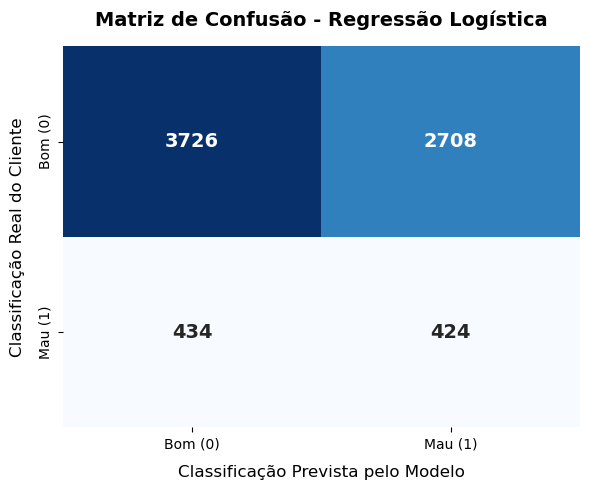

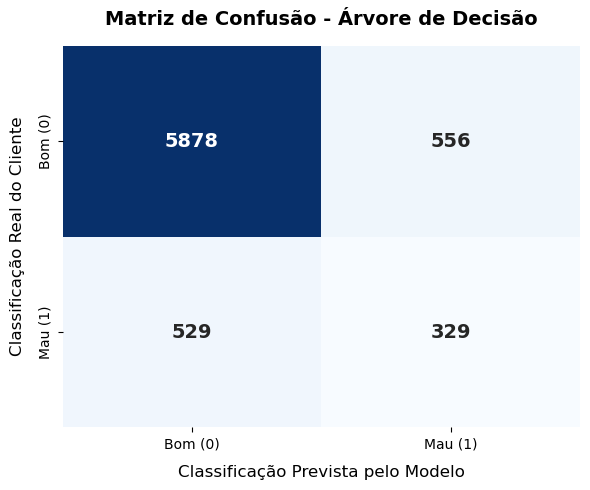

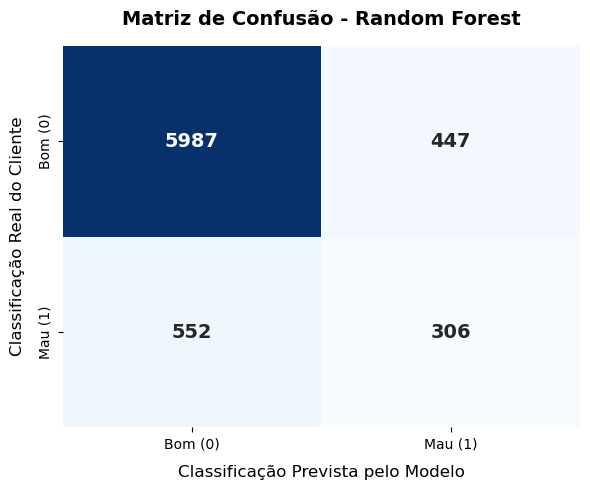

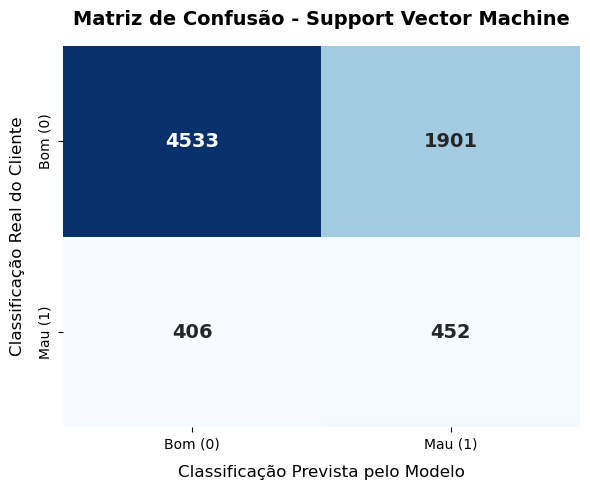

In [11]:
# Gera um gráfico visual para cada modelo treinado
for nome_modelo, y_pred in previsoes.items():
    plotar_matriz_confusao(y_test, y_pred, nome_modelo)
